# FITTING NOTEBOOK - NIRISS

In [1]:
# ALWAYS RUN THE FIRST THREE CELLS
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
import transitspectroscopy as ts
from tqdm import tqdm
import pandas as pd

import seaborn as sns
sns.set_style('ticks')

In [2]:
# Open data file (transitspectroscopy output)
path = '/media/peng/KINGSTON/'
with open(path + '_jw03385004001_toi1130_niriss_lcs.pkl', 'rb') as file:
    data = pickle.load(file)

# NIRISS
# data is a dict with 3 entris:
# 1. order1: Contains spectral light curves and white light for 0.9 to 2.8 micron
# --> each one of these keys contains more dicts, for example, data['order1']['spectral light curves'] shows each {wavelength: {flux: [...], errors: [...]}} or just flux and errors for wl
# 2. order2: same as order 1 but for 0.6 to 1.4 micron
# 3. times: Just an array with times

In [3]:
# Define planetary parameters
per = 4.074554             # Period (Days)
t0 = 2460547.15          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# Define planet and instrument name
star = 'TOI-1130'
pn = 'TOI-1130b'
itm = 'Order2'

# White Light Curves

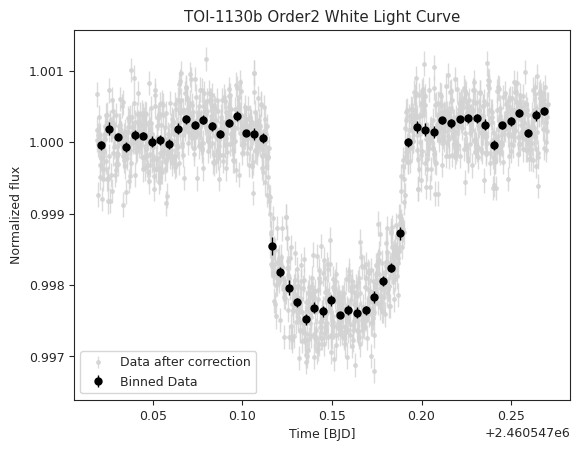

In [4]:
# Define time and flux data points for white light curves
t = data['times']
f_wl = data['order'+itm[-1]]['white light']['flux']   # These are in the millions and the errors are in the thousands, so don't bother plotting before correction for NIRISS
ferr_wl = data['order'+itm[-1]]['white light']['errors']

# Normalize flux such that the out-of-transit flux = 1
f_med = np.nanmedian(f_wl[:100])
f_wl, ferr_wl = f_wl / f_med, ferr_wl / f_med
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data after correction', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized flux')

# Define root-mean-squared values
rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [5]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [6]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
#--------------------------------------------------------------------------------------------------

# # Linear
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#           'theta0_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#           [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
#--------------------------------------------------------------------------------------------------

# Linear + GP
params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
           'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform', 'loguniform', 'loguniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
           [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]

priors = juliet.generate_priors(params, dists, hyperps) 

In [7]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit')
# #---------------------------------------------------------------------------------------------

# # Linear
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_GP')
#---------------------------------------------------------------------------------------------

# Linear + GP
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

67348it [15:19, 73.22it/s, batch: 1 | bound: 3 | nc: 1 | ncall: 1830478 | eff(%):  3.624 | loglstar: 8643.131 < 8648.486 < 8646.043 | logz: 8591.355 +/-  0.237 | stop:  0.765]           


done


In [8]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

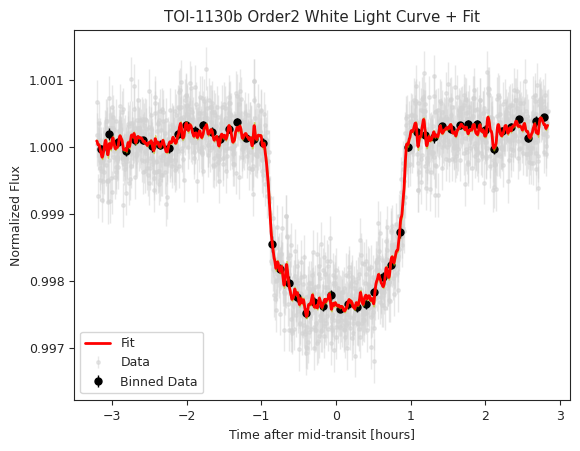

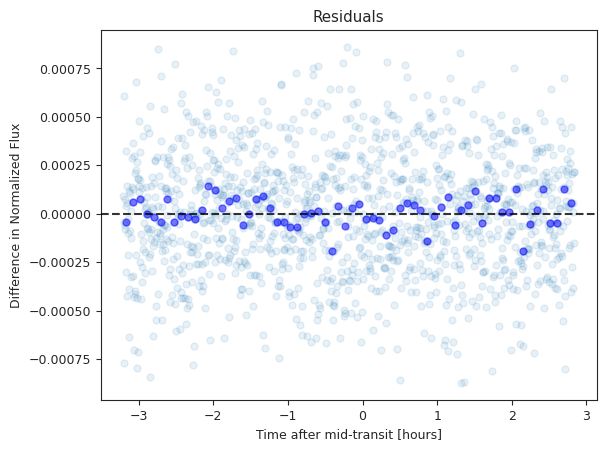

In [9]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.nanmedian(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' '+itm+ ' White Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+itm+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+itm+'_residuals.png')

plt.show()

2026-06-12 14:38:01,855 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:01,907 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,051 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,125 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,178 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,206 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,235 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,307 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,365 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,394 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,421 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 14:38:02,445 - stpipe - WARNING - Too few points to cr

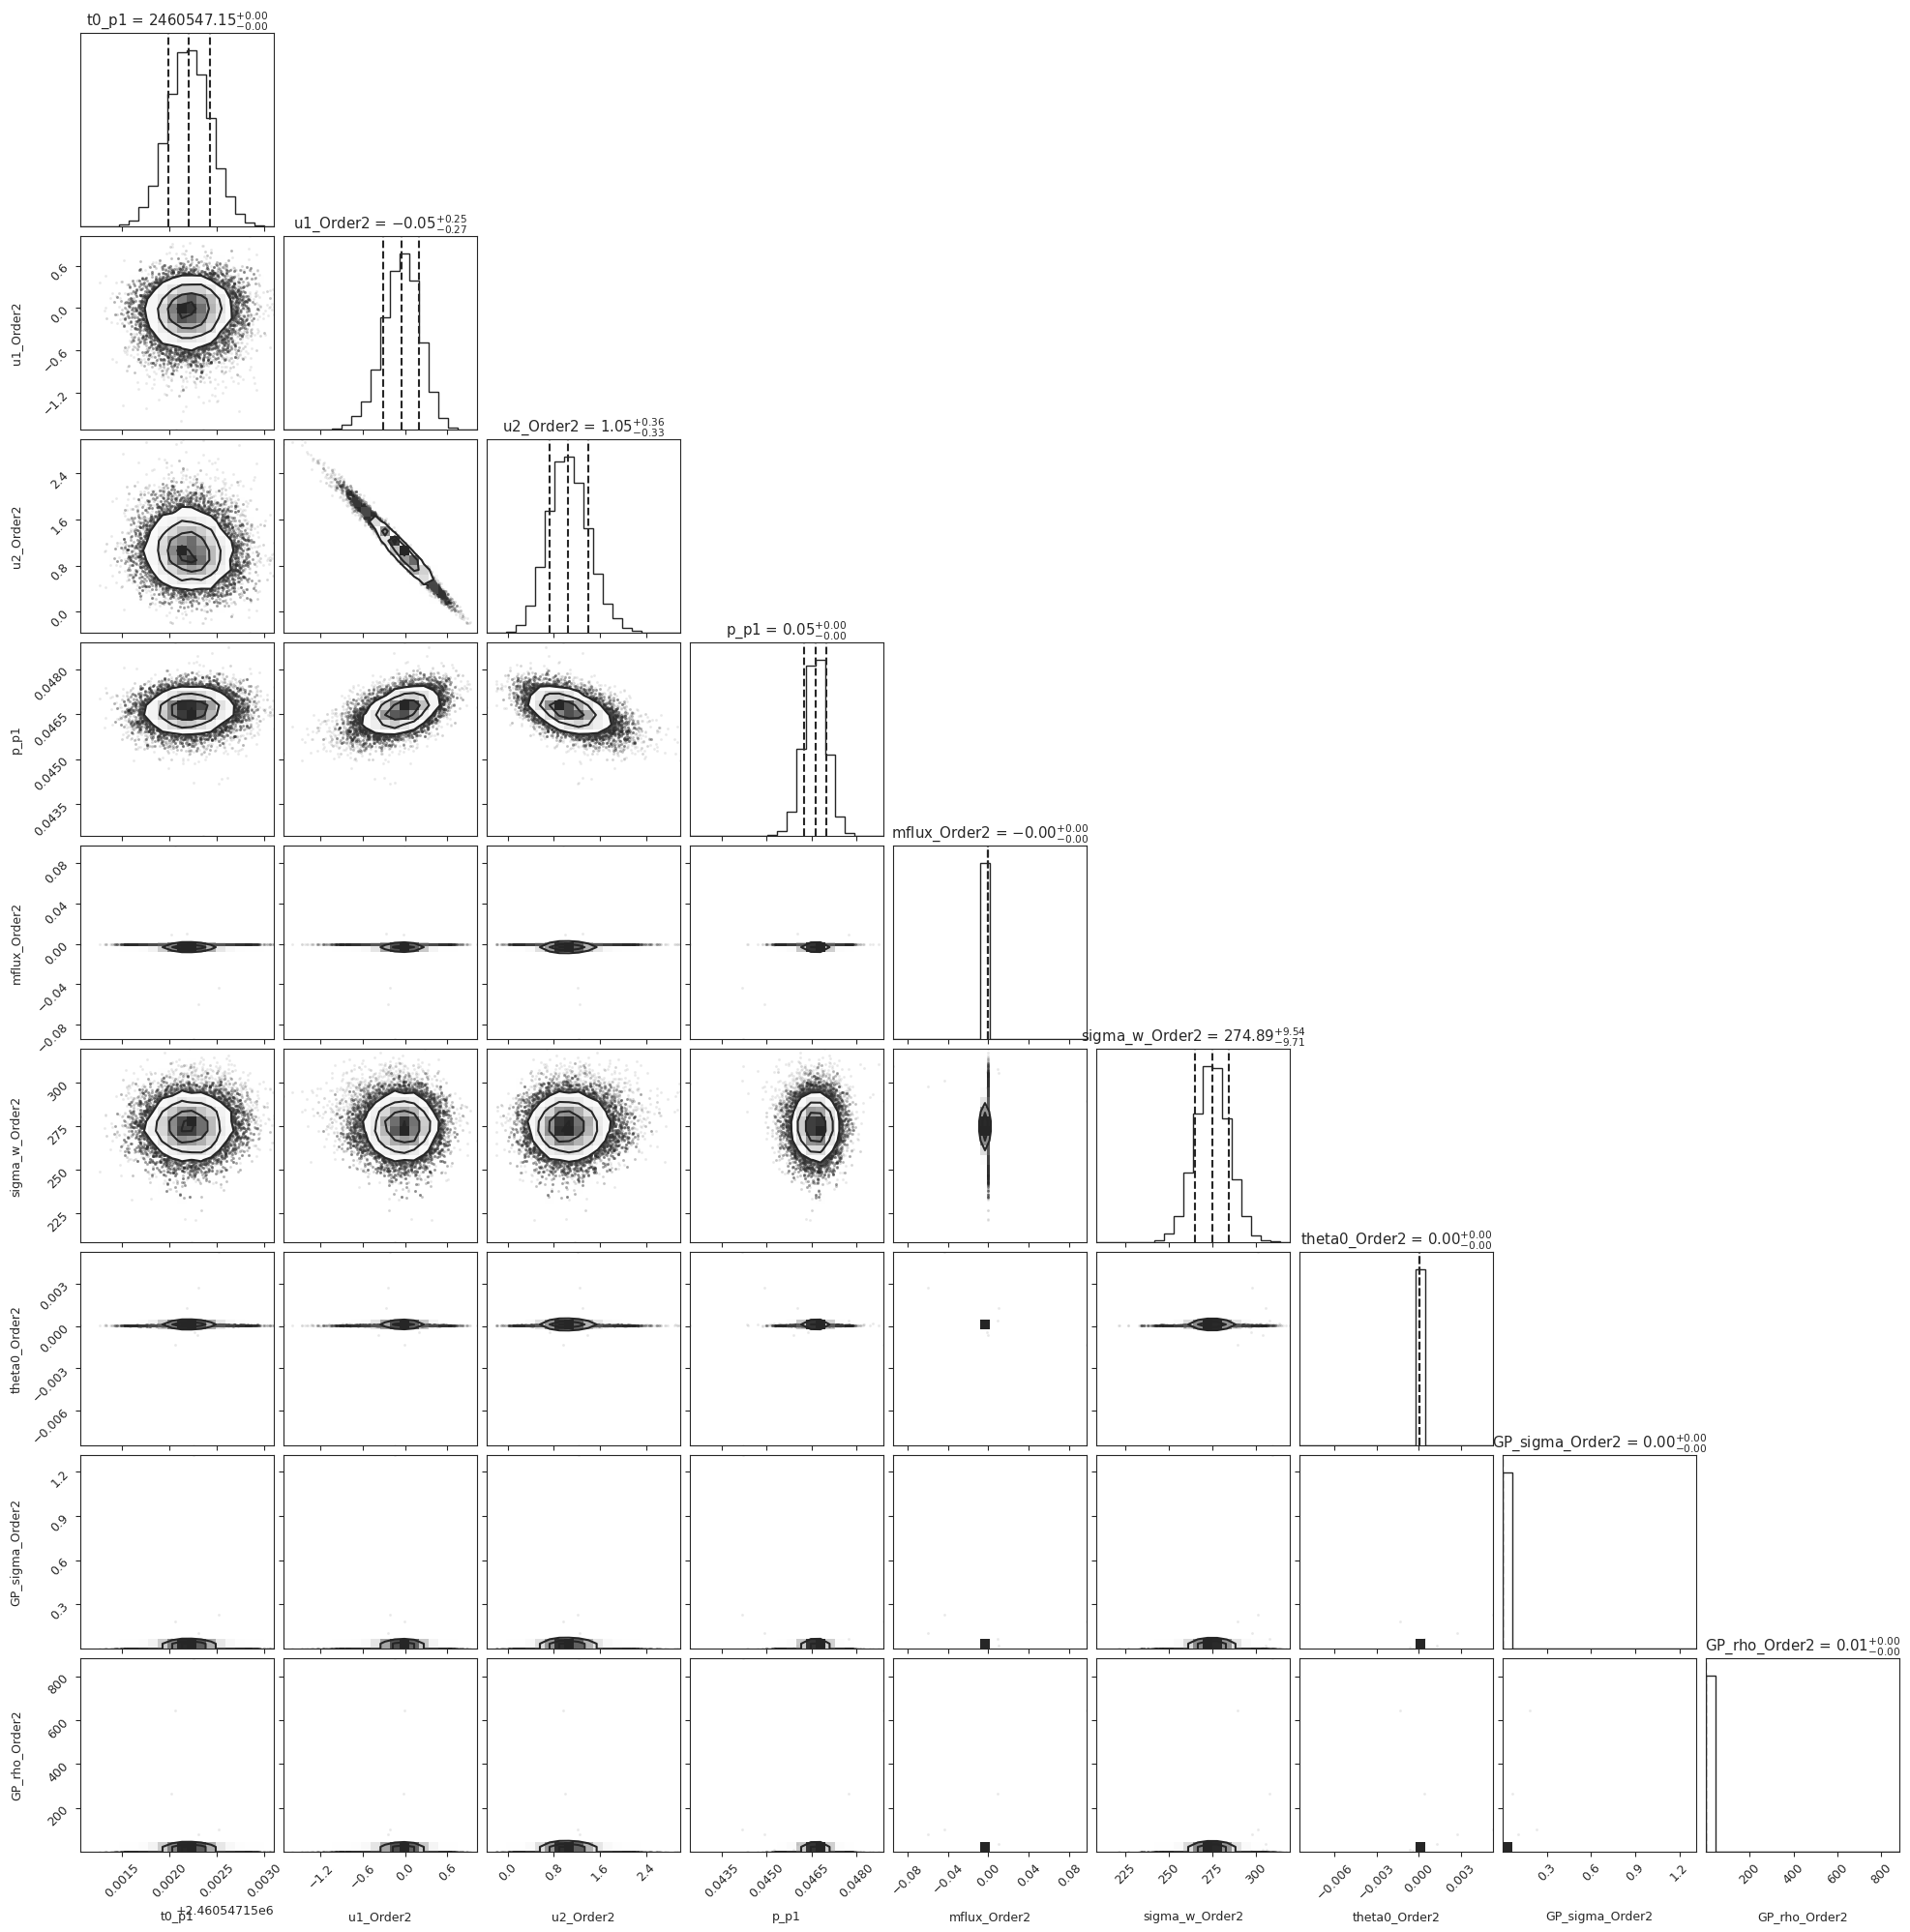

In [10]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear+GP/'+itm+'_corner.png')
plt.show()

In [13]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
# print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
print('With linear + GP:', results.posteriors['lnZ'])

With linear + GP: 8591.369694665611


In [14]:
# Get transit depth for white light curve
td_list = (results.posteriors['posterior_samples']['p_p1']**2) * 100

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Transit Depth:', td, '\n', 
      'Errors:', tderr)

Transit Depth: 0.2174002439244842 
 Errors: 0.0035708388114542773


# Spectroscopic Light Curves

In [5]:
t = data['times']
wl = [i for i in data['order'+itm[-1]]['spectral light curves']]   # Reversed order for some reason but it's ok

# Each data['order#']['spectral light curves'][wl[0]]['flux'] is an array that contains the corresponding spectroscopic light curve in ppm
# Now store all spectroscopics in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
spec_lcs = {}
for i in range(len(wl)):
    wavelength = wl[i]
    slc = data['order'+itm[-1]]['spectral light curves'][wavelength]['flux']
    slcerr = data['order'+itm[-1]]['spectral light curves'][wavelength]['errors']

    # Normalize each light curve
    slc_med = np.nanmedian(slc[:100])
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = slc / slc_med
    spec_lcs[wavelength]['ferr'] = slcerr / slc_med

# for i in spec_lcs: 
#     print(i)

In [8]:
# Bin light curves since spec_lcs has spectroscopic light curves in instrument's native resolution
bin_slc = {}
for i in range(0, len(wl) - 10, 10):
    wl_mean = np.round(np.mean(wl[i: i+10]), 7)  # This is just to name the bin
    
    bin_slc[wl_mean] = {}
    bin_slc[wl_mean]['f'] = 0
    bin_slc[wl_mean]['ferr'] = 0

    # Add every 10 spectroscopic light curves together, then normalize flux to 1
    for j in wl[i: i+10]:
        bin_slc[wl_mean]['f'] += spec_lcs[j]['f']
        bin_slc[wl_mean]['ferr'] += spec_lcs[j]['ferr']

    fbin_med = np.nanmedian(bin_slc[wl_mean]['f'][:100])
    bin_slc[wl_mean]['f'] = bin_slc[wl_mean]['f'] / fbin_med
    bin_slc[wl_mean]['ferr'] = bin_slc[wl_mean]['ferr'] / fbin_med

# Run this to see all binned wavelengths
# for i in bin_slc:
#     print(i)

print(bin_slc[1.3153741])

{'f': array([1.00841599, 1.00961156, 0.96052169, ..., 1.00884358, 0.99023931,
       1.01143221]), 'ferr': array([0.027149 , 0.027149 , 0.027149 , ..., 0.0271241, 0.0271241,
       0.0271241])}


In [9]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

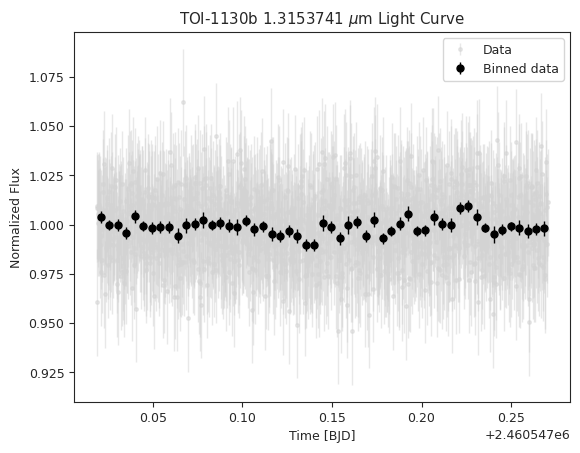

In [10]:
# Define time and flux data points - spectroscopic light curves

# trial_list = [3.8534895, 3.9474171, 4.0612377, 4.2149372, 4.4014793, 4.4745839, 4.6204934, 4.8121505, 4.9569554, 5.1012321]

trial_wl = 1.3153741
t = t     # Sorry I just feel like defining time again for the billionth time

# Uncomment to use native resolution
# f_s = spec_lcs[trial_wl]['f']
# ferr_s = spec_lcs[trial_wl]['ferr']

# Uncomment to use bin_slc
f_s = bin_slc[trial_wl]['f']
ferr_s = bin_slc[trial_wl]['ferr']

# Don't need to normalize since it's already normalized in the dict, so just bin
tbin, fsbin, ferrsbin = juliet.bin_data(t, f_s, 25)

plt.errorbar(t, f_s, yerr = ferr_s, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data', zorder = 1)
plt.errorbar(tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)
plt.title(pn+' '+str(round(trial_wl, 7))+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized Flux')
plt.legend()

plt.show()

In [11]:
# For now, only define parameters + linear model for NRS1 and 2
t0 = 2460547.1522035785 # for Order 1
# t0 =  - # for Order 2

params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
           'GP_sigma_'+itm, 'GP_rho_'+itm]

dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'loguniform', 'loguniform']

hyperps = [per, t0, a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
           [1e-8, 1e2], [1e-8, 1e3]]

priors = juliet.generate_priors(params, dists, hyperps)

# Put data into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 GP_regressors_lc = GP_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+str(round(trial_wl, 7))+'_fit')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

18471it [02:09, 143.10it/s, batch: 4 | bound: 1 | nc: 1 | ncall: 386273 | eff(%):  4.480 | loglstar: 3309.224 < 3312.624 < 3309.663 | logz: 3305.502 +/-  0.059 | stop:  0.908]        


done


In [12]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_s**2)

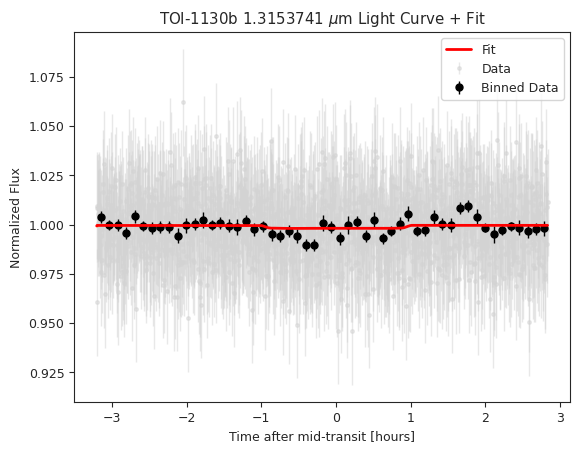

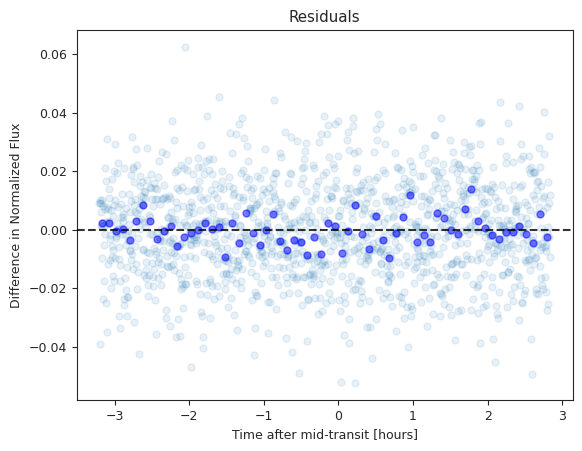

In [13]:
# Normalize time so it's relative to mid-transit
norm_t = (t - t0) * 24
norm_tbin = (tbin - t0) * 24

# Scatter data
plt.errorbar(norm_t, f_s, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+ ' '+str(round(trial_wl, 7))+ ' $\mu$m Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_s - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_residuals.png')
plt.show()

2026-06-12 15:44:41,947 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 15:44:42,095 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 15:44:42,128 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 15:44:42,285 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 15:44:42,318 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 15:44:42,355 - stpipe - WARNING - Too few points to create valid contours


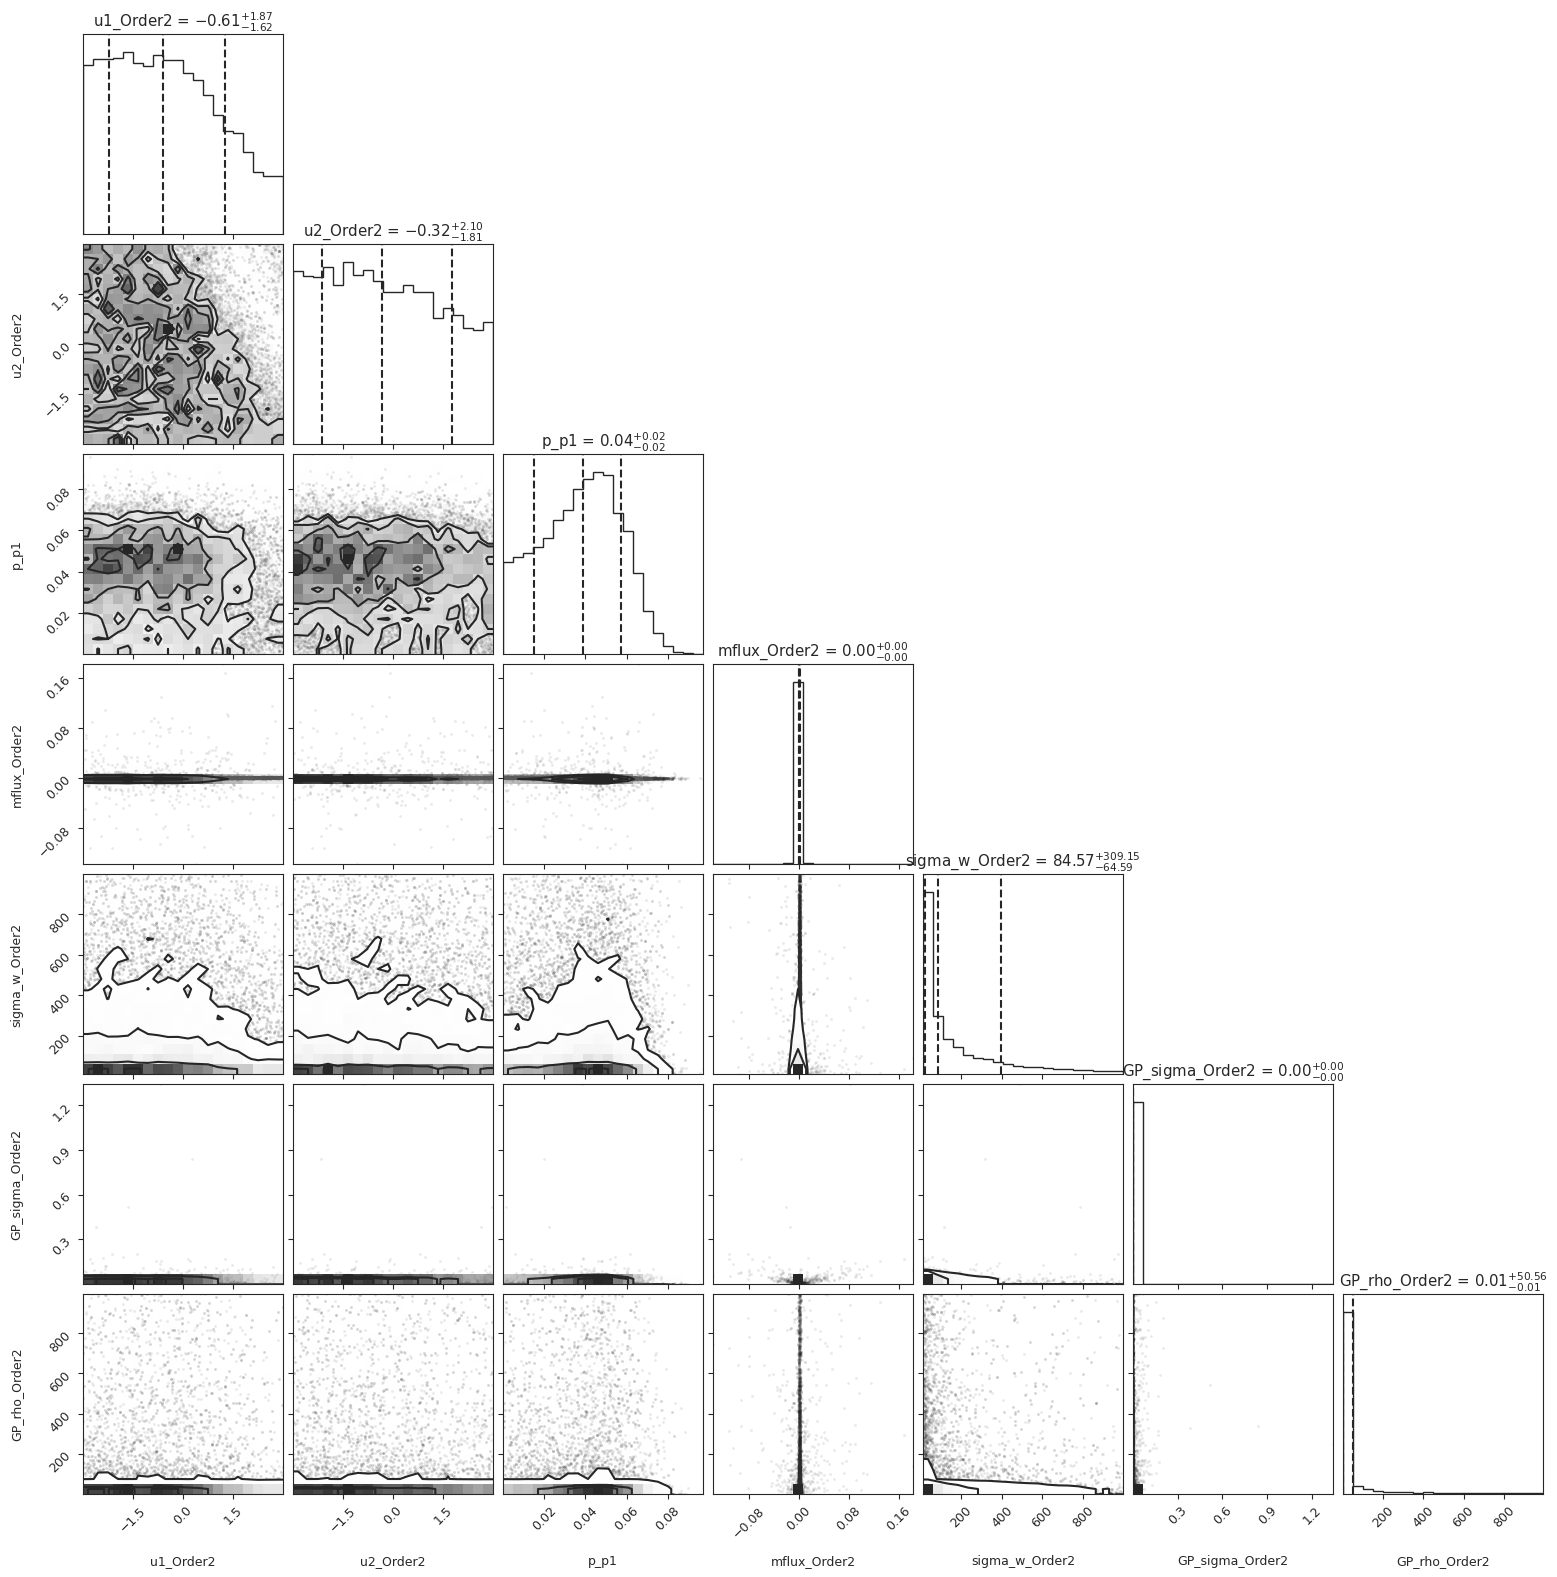

Log Evidence: 3305.5156240315155


In [14]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles=True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_corner.png')
plt.show()

print('Log Evidence:', results.posteriors['lnZ'])

In [15]:
# Get best fit value of p_p1 and convert to transit depth
td_list = (results.posteriors['posterior_samples']['p_p1']**2) * 100

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Wavelength:', trial_wl, '\n',
      'Transit Depth:', td, '\n', 
      'Errors:', tderr)

Wavelength: 1.3153741 
 Transit Depth: 0.15086365097183843 
 Errors: 0.14261581360658424


In [16]:
# Run speclc_fit.py which loops through all indices of spec_lcs or any similar dict and fits each light curve
%run niriss_speclc_fit.py

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_1.4158391_fit/_dynesty_DNS_posteriors.pkl


26212it [03:20, 130.58it/s, batch: 1 | bound: 4 | nc: 1 | ncall: 616523 | eff(%):  4.073 | loglstar: 3917.855 < 3922.187 < 3920.723 | logz: 3905.178 +/-  0.121 | stop:  0.809]           
2026-06-12 16:30:41,369 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,482 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,506 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,619 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,646 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,672 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,792 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,843 - stpipe - WARNING - Too few points to create valid contours
2026-06-12 16:30:41,872 - stpipe - WARNING - Too few points to create valid contours
26343it [03:27, 127.20it/s, batch: 0 | bound: 30

KeyboardInterrupt: 

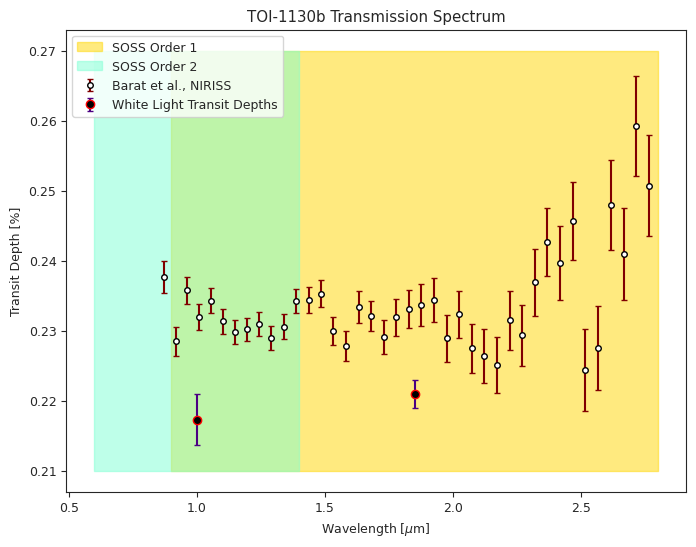

In [27]:
# Plot wavelength ranges for each order
o1, o2 = [0.9, 2.8], [0.6, 1.4]
ys = [0.21, 0.27]   # This also indirectly sets the ylim
plt.fill_betweenx(ys, o1[0], o1[1], color = 'gold', alpha = 0.5, zorder = 1, label = 'SOSS Order 1')
plt.fill_betweenx(ys, o2[0], o2[1], color = 'aquamarine', alpha = 0.5, zorder = 1, label = 'SOSS Order 2')

# Plot transit depths from white light curves
central_bins = [1.85, 1.0]
central_td = [0.22100553852421323, 0.21729974049462947]
central_tderr = [0.001982675994479956, 0.003600218438427502]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)

# Plot spectrum from Barat et al., 2026 for comparison
barat_niriss = pd.read_csv('barat_toi1130b_spectrum_niriss.csv')
barat_wl_niriss = barat_niriss['CENTRALWAVELNG']
barat_td_niriss = barat_niriss['PL_TRANDEP']
barat_tderr_niriss = barat_niriss['PL_TRANDEPERR1']

plt.errorbar(barat_wl_niriss, barat_td_niriss, yerr = barat_tderr_niriss, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'maroon', label = 'Barat et al., NIRISS', zorder = 2)

# Order 1
# data points here
# maybe bin again here
plt.errorbar(samp_binx, samp_biny, yerr = samp_binyerr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'Order 1 Data', zorder = 8)

# Order 2
# data points here
# maybe bin again here
plt.errorbar(samp_binx, samp_fixbiny, yerr = samp_fixbinyerr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'palegreen', mec = 'k', color = 'darkturquoise', label = 'NRS2 Data', zorder = 8)


plt.title(pn+' Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')

plt.legend()
plt.show()